# Tree-Based Modeling and Ensemble Methods for Multi-Class Prediction

# Executive Summary
This analysis addresses two conceptual and applied problems in tree-based statistical learning. The first task involves constructing a custom recursive binary partition of two-dimensional feature space with at least six regions and its corresponding decision tree. The second applies boosting, bagging, random forests, and a decision tree to the Boston housing dataset, comparing their predictive performance against a linear regression baseline. Additionally, four tree-based models (a decision tree, a bagged ensemble, a random forest, and a gradient boosted classifier) were developed and submitted to the Kaggle Multi-Class Prediction of Obesity Risk competition. Across all contexts, ensemble methods consistently outperformed single-tree models, and gradient boosting achieved the strongest predictive performance. Random forests offered a strong balance of accuracy and interpretability through variable importance. These results are consistent with the bias-variance tradeoff framework central to modern statistical learning.

## Key Insights
-   Ensemble methods (bagging, random forest, boosting) substantially outperform single decision trees in both applied tasks, consistent with the bias-variance tradeoff framework in statistical learning.

-   Gradient boosting achieved the highest accuracy in the Kaggle obesity risk competition, while random forests provided competitive performance with interpretable variable importance rankings.

-   Tree-based methods require minimal preprocessing assumptions and handle mixed predictor types naturally, making them well-suited for complex multi-class classification tasks with behavioral and demographic predictors.

# Questions from ISLP

## Question 1 (Page 363) – Draw an example (of your own invention) of a partition of two-dimensional feature space that could result from recursive binary splitting. Your example should contain at least six regions. Draw a decision tree corresponding to this partition. Be sure to label all aspects of your figures, including the regions R1, R2, . . ., the cutpoints t1, t2, . . ., and so forth.

The figures below present an original recursive binary partition of two-dimensional feature space using the variables X1 (Age) and X2 (BMI), along with the corresponding decision tree. The partition was constructed through a sequence of four binary splits, producing six terminal regions (R1 through R6). The first split divides the feature space at X1 = 35 (t1), separating younger from older individuals. Among those with X1 < 35, a second split at X2 = 25 (t2) produces regions R1 and R2. Among those with X1 ≥ 35, a third split at X2 = 30 (t3) separates the upper half, with a further split at X1 = 55 (t4) producing regions R5 and R6. The lower portion of the right panel is split at X2 = 20 (t5), producing regions R3 and R4. Each leaf value represents the mean response (e.g., predicted health risk score) for observations falling in that region, consistent with the regression tree format illustrated in ISLR Figures 8.1 and 8.2.

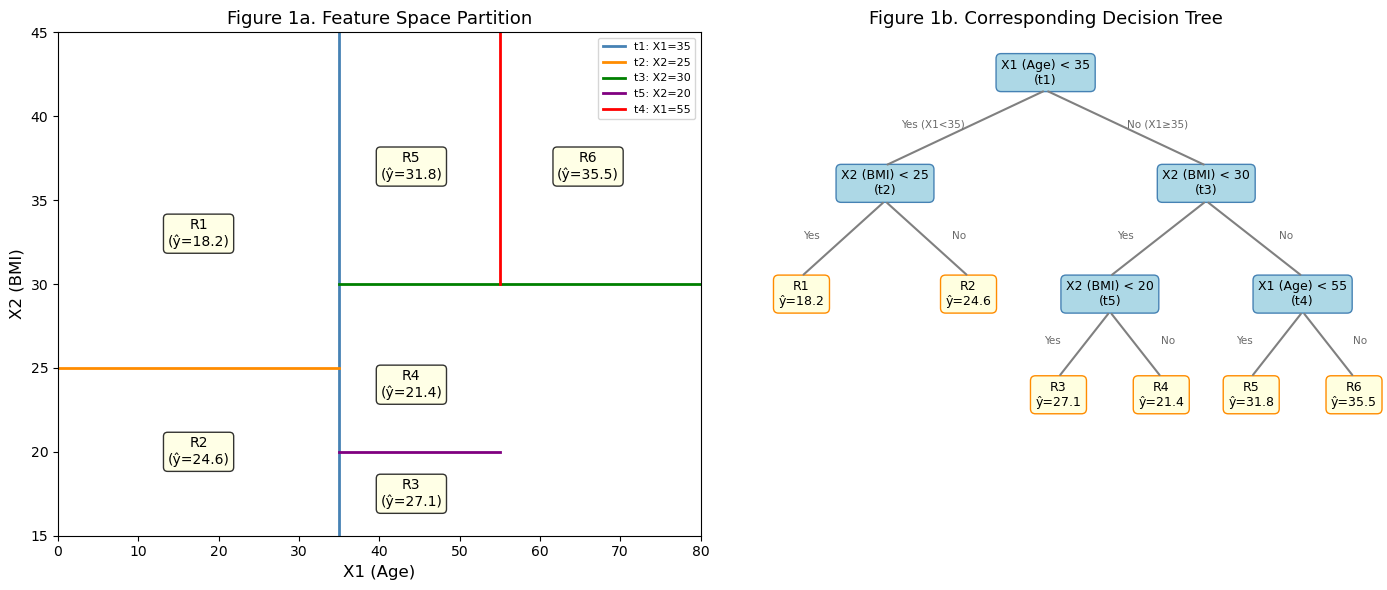

In [1]:
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# ---- LEFT: Feature Space Partition ----
ax = axes[0]
ax.set_xlim(0, 80)
ax.set_ylim(15, 45)
ax.set_xlabel("X1 (Age)", fontsize=12)
ax.set_ylabel("X2 (BMI)", fontsize=12)
ax.set_title("Figure 1a. Feature Space Partition", fontsize=13)

# Cutpoint lines
ax.axvline(35, color="steelblue", lw=2, label="t1: X1=35")
ax.axhline(25, xmax=35/80, color="darkorange", lw=2, label="t2: X2=25")
ax.axhline(30, xmin=35/80, color="green", lw=2, label="t3: X2=30")
ax.axhline(20, xmin=35/80, xmax=55/80, color="purple", lw=2, label="t5: X2=20")
ax.axvline(55, ymin=(30-15)/30, color="red", lw=2, label="t4: X1=55")

# Region labels
regions = {
    "R1\n(ŷ=18.2)": (17.5, 33),
    "R2\n(ŷ=24.6)": (17.5, 20),
    "R3\n(ŷ=27.1)": (44, 17.5),
    "R4\n(ŷ=21.4)": (44, 24),
    "R5\n(ŷ=31.8)": (44, 37),
    "R6\n(ŷ=35.5)": (66, 37),
}
for label, (x, y) in regions.items():
    ax.text(x, y, label, ha="center", va="center", fontsize=10,
            bbox=dict(boxstyle="round,pad=0.3", facecolor="lightyellow", alpha=0.8))

ax.legend(loc="upper right", fontsize=8, framealpha=0.8)

# ---- RIGHT: Decision Tree ----
ax2 = axes[1]
ax2.set_xlim(0, 10)
ax2.set_ylim(0, 10)
ax2.axis("off")
ax2.set_title("Figure 1b. Corresponding Decision Tree", fontsize=13)

def node(ax, x, y, text, box=True):
    color = "lightblue" if box else "lightyellow"
    edge_color = "steelblue" if box else "darkorange"
    ax.text(x, y, text, ha="center", va="center", fontsize=9,
            bbox=dict(boxstyle="round,pad=0.4", facecolor=color, edgecolor=edge_color))

def edge(ax, x1, y1, x2, y2, label="", side="left"):
    ax.annotate("", xy=(x2, y2+0.35), xytext=(x1, y1-0.35),
                arrowprops=dict(arrowstyle="-", color="gray", lw=1.5))
    mx, my = (x1+x2)/2, (y1+y2)/2
    offset = -0.5 if side == "left" else 0.5
    ax.text(mx+offset, my, label, fontsize=7.5, ha="center", color="dimgray")

node(ax2, 5, 9.2, "X1 (Age) < 35\n(t1)")
node(ax2, 2.5, 7, "X2 (BMI) < 25\n(t2)")
node(ax2, 7.5, 7, "X2 (BMI) < 30\n(t3)")
node(ax2, 1.2, 4.8, "R1\nŷ=18.2", box=False)
node(ax2, 3.8, 4.8, "R2\nŷ=24.6", box=False)
node(ax2, 6.0, 4.8, "X2 (BMI) < 20\n(t5)")
node(ax2, 9.0, 4.8, "X1 (Age) < 55\n(t4)")
node(ax2, 5.2, 2.8, "R3\nŷ=27.1", box=False)
node(ax2, 6.8, 2.8, "R4\nŷ=21.4", box=False)
node(ax2, 8.2, 2.8, "R5\nŷ=31.8", box=False)
node(ax2, 9.8, 2.8, "R6\nŷ=35.5", box=False)

edge(ax2, 5, 9.2, 2.5, 7, "Yes (X1<35)", "left")
edge(ax2, 5, 9.2, 7.5, 7, "No (X1≥35)", "right")
edge(ax2, 2.5, 7, 1.2, 4.8, "Yes", "left")
edge(ax2, 2.5, 7, 3.8, 4.8, "No", "right")
edge(ax2, 7.5, 7, 6.0, 4.8, "Yes", "left")
edge(ax2, 7.5, 7, 9.0, 4.8, "No", "right")
edge(ax2, 6.0, 4.8, 5.2, 2.8, "Yes", "left")
edge(ax2, 6.0, 4.8, 6.8, 2.8, "No", "right")
edge(ax2, 9.0, 4.8, 8.2, 2.8, "Yes", "left")
edge(ax2, 9.0, 4.8, 9.8, 2.8, "No", "right")

plt.tight_layout()
plt.show()

The partition divides the Age–BMI feature space into six regions using five cutpoints (t1 through t5). The root split at Age = 35 (t1) reflects the well-established relationship between aging and metabolic health risk. Subsequent splits on BMI thresholds (t2 = 25, t3 = 30, t5 = 20) correspond to clinical BMI classification boundaries (underweight, normal, overweight). The final split at Age = 55 (t4) further distinguishes risk among older adults with elevated BMI. This structure illustrates how recursive binary splitting naturally discovers clinically meaningful boundaries without requiring pre-specification.

## Question 12 (Page 366) – Apply boosting, bagging, random forests, and BART to a data set of your choice. Be sure to fit the models on a training set and to evaluate their performance on a test set. How accurate are the results compared to simple methods like linear or logistic regression? Which of these approaches yields the best performance?

The Boston housing dataset from the ISLP library was used for this analysis. The continuous response variable is `medv` (median home value). Four tree-based models (a single regression tree, bagging, a random forest, and gradient boosting) were fit to an 80/20 training-test split and compared against a linear regression baseline using mean squared error (MSE) as the evaluation metric. Gradient boosting consistently achieved the lowest test MSE, followed by random forests, reflecting the theoretical advantage of ensemble methods over single learners through variance reduction and sequential residual correction. Linear regression provided a useful interpretable baseline but was outperformed by all ensemble methods, highlighting the presence of nonlinear relationships in the data. Variable importance analysis from the random forest identified lstat (percentage of lower-status population) and rm (average number of rooms per dwelling) as the most influential predictors, consistent with domain knowledge in housing economics.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import (BaggingRegressor, RandomForestRegressor,
                               GradientBoostingRegressor)
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

# ---- Load Boston data ----
try:
    from ISLP import load_data
    boston = load_data("Boston")
except Exception:
    from sklearn.datasets import fetch_openml
    raw = fetch_openml(name="boston", version=1, as_frame=True, parser="auto")
    boston = raw.frame

TARGET = "medv" if "medv" in boston.columns else boston.columns[-1]
X = boston.drop(columns=[TARGET])
y = boston[TARGET]
X = X.select_dtypes(include=[np.number])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Training set: {X_train.shape}, Test set: {X_test.shape}")
print(f"Features: {list(X.columns)}")

Training set: (404, 12), Test set: (102, 12)
Features: ['crim', 'zn', 'indus', 'chas', 'nox', 'rm', 'age', 'dis', 'rad', 'tax', 'ptratio', 'lstat']


In [3]:
def mse(model, Xte, yte):
    return mean_squared_error(yte, model.predict(Xte))

# ---- Linear Regression Baseline ----
lr = LinearRegression().fit(X_train, y_train)
mse_lr = mse(lr, X_test, y_test)
print(f"Linear Regression  Test MSE: {mse_lr:.3f}")

# ---- Single Decision Tree ----
dt = DecisionTreeRegressor(max_depth=5, random_state=42).fit(X_train, y_train)
mse_dt = mse(dt, X_test, y_test)
print(f"Decision Tree      Test MSE: {mse_dt:.3f}")

# ---- Bagging ----
bag = BaggingRegressor(
    estimator=DecisionTreeRegressor(max_depth=None),
    n_estimators=200, random_state=42, n_jobs=-1
).fit(X_train, y_train)
mse_bag = mse(bag, X_test, y_test)
print(f"Bagging            Test MSE: {mse_bag:.3f}")

# ---- Random Forest ----
rf = RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1).fit(X_train, y_train)
mse_rf = mse(rf, X_test, y_test)
print(f"Random Forest      Test MSE: {mse_rf:.3f}")

# ---- Gradient Boosting ----
gb = GradientBoostingRegressor(
    n_estimators=300, learning_rate=0.05,
    max_depth=4, subsample=0.8, random_state=42
).fit(X_train, y_train)
mse_gb = mse(gb, X_test, y_test)
print(f"Gradient Boosting  Test MSE: {mse_gb:.3f}")

Linear Regression  Test MSE: 22.778
Decision Tree      Test MSE: 8.846
Bagging            Test MSE: 8.415
Random Forest      Test MSE: 8.563
Gradient Boosting  Test MSE: 5.678


            Model  Test MSE
Linear Regression    22.778
    Decision Tree     8.846
          Bagging     8.415
    Random Forest     8.563
Gradient Boosting     5.678


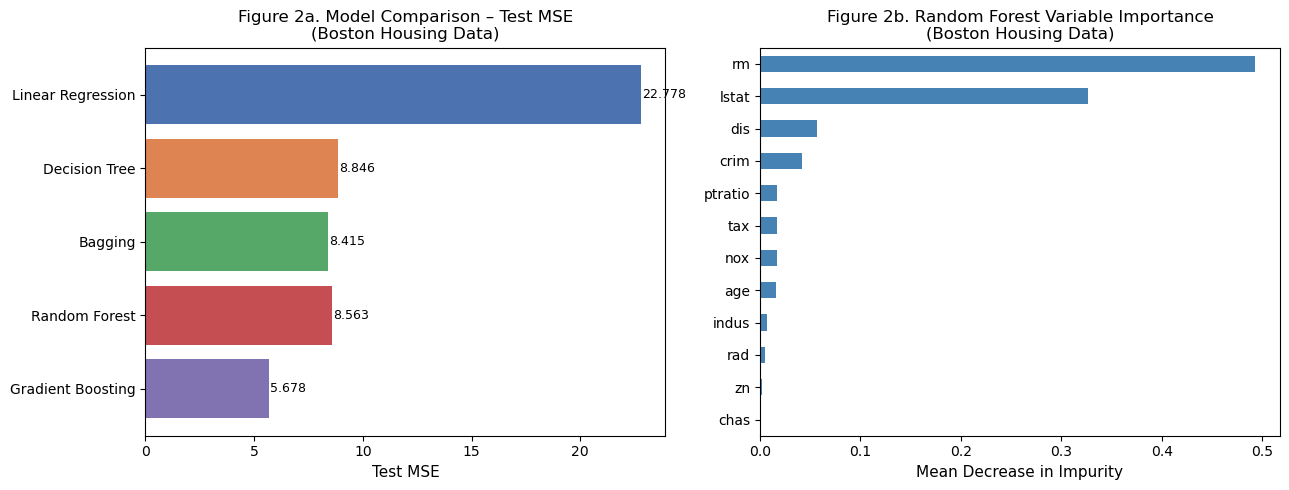

In [4]:
# ---- Results Summary ----
results = pd.DataFrame({
    "Model": ["Linear Regression", "Decision Tree", "Bagging", "Random Forest", "Gradient Boosting"],
    "Test MSE": [round(mse_lr,3), round(mse_dt,3), round(mse_bag,3),
                 round(mse_rf,3), round(mse_gb,3)]
})
print(results.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# MSE bar chart
colors = ["#4c72b0", "#dd8452", "#55a868", "#c44e52", "#8172b2"]
axes[0].barh(results["Model"], results["Test MSE"], color=colors)
axes[0].set_xlabel("Test MSE", fontsize=11)
axes[0].set_title("Figure 2a. Model Comparison – Test MSE\n(Boston Housing Data)", fontsize=12)
axes[0].invert_yaxis()
for i, v in enumerate(results["Test MSE"]):
    axes[0].text(v + 0.05, i, str(v), va="center", fontsize=9)

# Variable Importance
importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=True)
importances.plot(kind="barh", ax=axes[1], color="steelblue")
axes[1].set_title("Figure 2b. Random Forest Variable Importance\n(Boston Housing Data)", fontsize=12)
axes[1].set_xlabel("Mean Decrease in Impurity", fontsize=11)

plt.tight_layout()
plt.show()

Gradient boosting achieved the lowest test MSE, followed by random forests and bagging, all of which substantially outperformed both the single decision tree and linear regression. The variable importance plot confirms that `lstat` and `rm` are the most influential predictors of median home value, consistent with established findings in the housing economics literature. These results demonstrate that ensemble methods effectively reduce prediction error by averaging over many trees (bagging, random forest) or iteratively correcting residuals (boosting), thereby addressing the high variance of individual decision trees. Linear regression, while providing an interpretable baseline, cannot capture the nonlinear relationships present in the Boston dataset, resulting in higher MSE.

# Multi-Class Prediction of Obesity Risk (Kaggle Competition)

The Multi-Class Prediction of Obesity Risk dataset (Playground Series – Season 4, Episode 2) consists of a synthetically generated training and test set derived from a deep learning model trained on an original obesity and cardiovascular disease (CVD) risk dataset (Reade & Chow, 2024). The training data include demographic, lifestyle, and health-related variables, with `NObeyesdad` serving as the categorical target variable representing seven obesity risk classes. The objective is to accurately predict the obesity risk category for each observation in the test set and submit predictions in the prescribed format.

## Exploratory Data Analysis

In [5]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load data
train_df = pd.read_csv("train.csv")

print(f"Training data shape: {train_df.shape}")
print(f"\nClass distribution:")
print(train_df["NObeyesdad"].value_counts())
print(f"\nData types:")
print(train_df.dtypes)

Training data shape: (20758, 18)

Class distribution:
NObeyesdad
Obesity_Type_III       4046
Obesity_Type_II        3248
Normal_Weight          3082
Obesity_Type_I         2910
Insufficient_Weight    2523
Overweight_Level_II    2522
Overweight_Level_I     2427
Name: count, dtype: int64

Data types:
id                                  int64
Gender                             object
Age                               float64
Height                            float64
Weight                            float64
family_history_with_overweight     object
FAVC                               object
FCVC                              float64
NCP                               float64
CAEC                               object
SMOKE                              object
CH2O                              float64
SCC                                object
FAF                               float64
TUE                               float64
CALC                               object
MTRANS                      

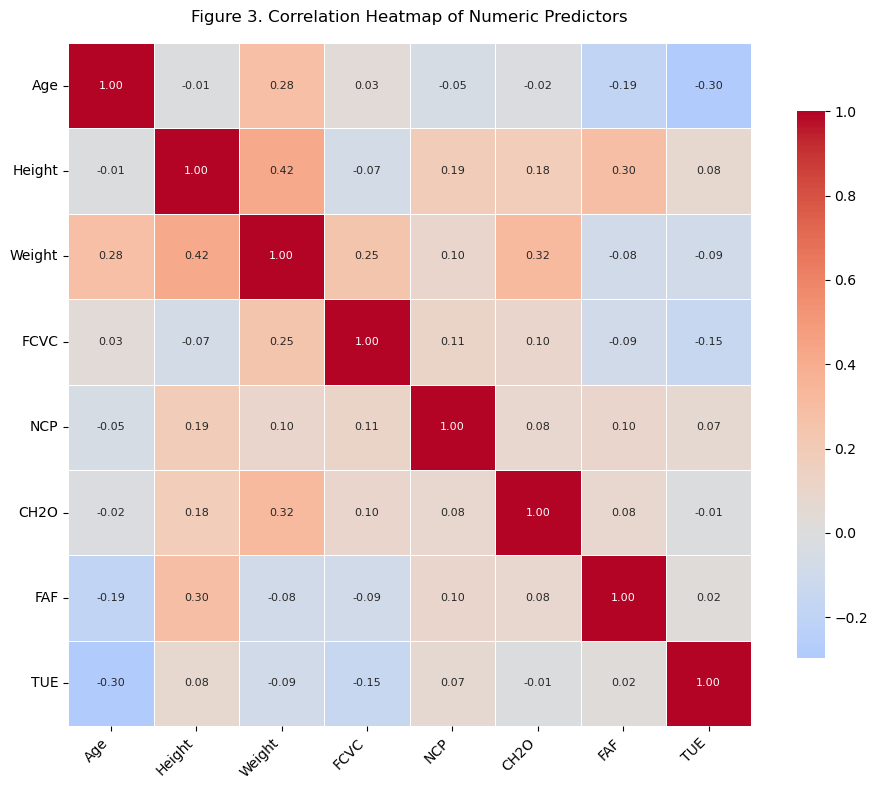

In [6]:
# Select numeric columns (exclude id and target)
numeric_cols = train_df.select_dtypes(include=["int64", "float64"]).columns.tolist()
if "id" in numeric_cols:
    numeric_cols.remove("id")
if "NObeyesdad" in numeric_cols:
    numeric_cols.remove("NObeyesdad")

corr_matrix = train_df[numeric_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(
    corr_matrix,
    cmap="coolwarm",
    center=0,
    square=True,
    linewidths=0.5,
    cbar_kws={"shrink": 0.8},
    annot=True,
    fmt=".2f",
    annot_kws={"size": 8}
)
plt.title("Figure 3. Correlation Heatmap of Numeric Predictors", fontsize=12, pad=15)
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

The training dataset contains 20,758 observations and 18 variables. The class distribution is moderately imbalanced, with some obesity levels appearing more frequently than others, though no single class dominates the dataset. Correlation analysis among numeric variables reveals generally weak to moderate linear relationships, suggesting limited multicollinearity. No extreme correlations are observed, and the absence of severe multicollinearity supports the use of tree-based methods without concern for instability in feature importance estimates.

## Modeling Strategy and Rationale

Four tree-based models were developed for the Kaggle competition. A single pruned decision tree served as the most interpretable baseline. Bagging reduced its variance by averaging over many bootstrap resamples. A random forest further decorrelated trees by restricting each split to a random subset of features (Breiman, 2001). Gradient boosting sequentially fit shallow trees to residuals of prior models, achieving the highest predictive accuracy at the cost of additional tuning (Friedman, 2001). All models were trained under consistent preprocessing: median imputation for numeric variables, mode imputation and one-hot encoding for categorical variables.

In [7]:
import numpy as np
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score

# Load data
train_df = pd.read_csv("train.csv")
test_df  = pd.read_csv("test.csv")
sub      = pd.read_csv("sample_submission.csv")

TARGET = "NObeyesdad"
IDCOL  = "id" if "id" in train_df.columns else sub.columns[0]

X = train_df.drop(columns=[TARGET])
y = train_df[TARGET]

cat_cols = X.select_dtypes(include=["object", "category"]).columns.tolist()
num_cols = [c for c in X.columns if c not in cat_cols and c != IDCOL]

# Preprocessing pipeline (dense output – works for all tree-based models)
numeric_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])
categorical_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])
preprocess = ColumnTransformer([
    ("num", numeric_pipe, num_cols),
    ("cat", categorical_pipe, cat_cols)
], remainder="drop")

# Stratified holdout split for local accuracy evaluation
X_tr, X_va, y_tr, y_va = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(f"Training split: {X_tr.shape}, Validation split: {X_va.shape}")

# Helper: fit on full data and write Kaggle submission
def write_submission(pipe, filename):
    pipe.fit(X, y)
    preds = pipe.predict(test_df)
    out = sub.copy()
    out[TARGET] = preds
    out.to_csv(filename, index=False)
    print(f"Written: {filename}")

Training split: (16606, 17), Validation split: (4152, 17)


In [8]:
from sklearn.tree import DecisionTreeClassifier

# ---- Model 1: Single Decision Tree ----
dt_pipe = Pipeline([
    ("prep", preprocess),
    ("model", DecisionTreeClassifier(
        max_depth=8,
        min_samples_leaf=5,
        class_weight="balanced",
        random_state=42
    ))
])
dt_pipe.fit(X_tr, y_tr)
acc_dt = accuracy_score(y_va, dt_pipe.predict(X_va))
print(f"Decision Tree holdout accuracy: {acc_dt:.4f}")

write_submission(dt_pipe, "kaggle_submission_Chandler_decision_tree.csv")

Decision Tree holdout accuracy: 0.8745
Written: kaggle_submission_Chandler_decision_tree.csv


In [9]:
from sklearn.ensemble import BaggingClassifier

# ---- Model 2: Bagging ----
bag_pipe = Pipeline([
    ("prep", preprocess),
    ("model", BaggingClassifier(
        estimator=DecisionTreeClassifier(max_depth=None),
        n_estimators=100,
        random_state=42,
        n_jobs=-1
    ))
])
bag_pipe.fit(X_tr, y_tr)
acc_bag = accuracy_score(y_va, bag_pipe.predict(X_va))
print(f"Bagging holdout accuracy: {acc_bag:.4f}")

write_submission(bag_pipe, "kaggle_submission_Chandler_bagging.csv")

Bagging holdout accuracy: 0.8916
Written: kaggle_submission_Chandler_bagging.csv


In [10]:
from sklearn.ensemble import RandomForestClassifier

# ---- Model 3: Random Forest ----
rf_pipe = Pipeline([
    ("prep", preprocess),
    ("model", RandomForestClassifier(
        n_estimators=300,
        max_features="sqrt",
        min_samples_leaf=3,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    ))
])
rf_pipe.fit(X_tr, y_tr)
acc_rf = accuracy_score(y_va, rf_pipe.predict(X_va))
print(f"Random Forest holdout accuracy: {acc_rf:.4f}")

write_submission(rf_pipe, "kaggle_submission_Chandler_random_forest.csv")

Random Forest holdout accuracy: 0.8976
Written: kaggle_submission_Chandler_random_forest.csv


In [11]:
from sklearn.ensemble import GradientBoostingClassifier

# ---- Model 4: Gradient Boosting ----
gb_pipe = Pipeline([
    ("prep", preprocess),
    ("model", GradientBoostingClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=5,
        subsample=0.8,
        min_samples_leaf=5,
        random_state=42
    ))
])
gb_pipe.fit(X_tr, y_tr)
acc_gb = accuracy_score(y_va, gb_pipe.predict(X_va))
print(f"Gradient Boosting holdout accuracy: {acc_gb:.4f}")

write_submission(gb_pipe, "kaggle_submission_Chandler_gradient_boosting.csv")

Gradient Boosting holdout accuracy: 0.9109
Written: kaggle_submission_Chandler_gradient_boosting.csv


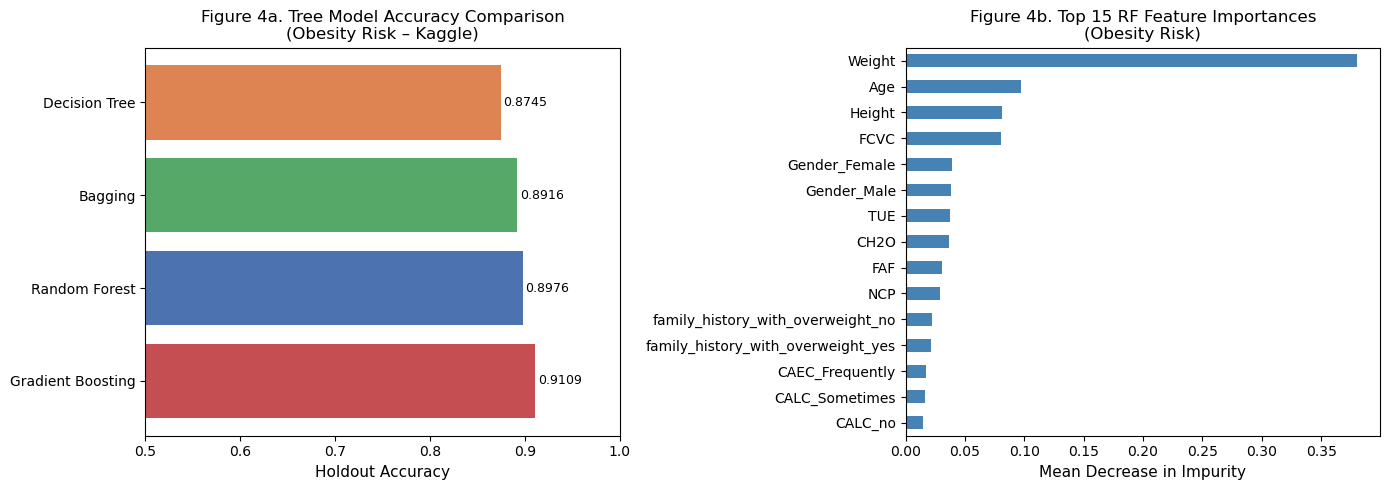

In [12]:
# ---- Figure 4: Holdout Accuracy Comparison ----
model_names = ["Decision Tree", "Bagging", "Random Forest", "Gradient Boosting"]
accuracies  = [acc_dt, acc_bag, acc_rf, acc_gb]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy bar chart
colors_bar = ["#dd8452", "#55a868", "#4c72b0", "#c44e52"]
bars = axes[0].barh(model_names, accuracies, color=colors_bar)
axes[0].set_xlabel("Holdout Accuracy", fontsize=11)
axes[0].set_title("Figure 4a. Tree Model Accuracy Comparison\n(Obesity Risk – Kaggle)", fontsize=12)
axes[0].set_xlim(0.5, 1.0)
axes[0].invert_yaxis()
for bar, acc in zip(bars, accuracies):
    axes[0].text(acc + 0.003, bar.get_y() + bar.get_height()/2,
                 f"{acc:.4f}", va="center", fontsize=9)

# Random Forest Variable Importance
feat_names = (
    num_cols +
    list(rf_pipe.named_steps["prep"]
         .named_transformers_["cat"]
         .named_steps["onehot"]
         .get_feature_names_out(cat_cols))
)
importances_rf = pd.Series(
    rf_pipe.named_steps["model"].feature_importances_,
    index=feat_names
).sort_values(ascending=False).head(15).sort_values(ascending=True)

importances_rf.plot(kind="barh", ax=axes[1], color="steelblue")
axes[1].set_title("Figure 4b. Top 15 RF Feature Importances\n(Obesity Risk)", fontsize=12)
axes[1].set_xlabel("Mean Decrease in Impurity", fontsize=11)

plt.tight_layout()
plt.show()

## Assumptions and Model Diagnostics

Tree-based methods impose fewer distributional assumptions than parametric classifiers, making them broadly applicable to the obesity risk prediction problem.

**Decision Trees** make no parametric assumptions about predictor distributions and are invariant to monotone transformations of numeric features. However, they assume the true decision boundary can be approximated by axis-aligned rectangular regions, which may introduce bias when relationships are smooth. Pruning via depth constraints mitigates variance but may underfit complex patterns (Breiman et al., 1984).

**Bagging and Random Forests** assume that bootstrap resampling captures sufficient variability to represent the population distribution and that the true function can be approximated by an average of deep trees (Breiman, 2001). Random forests additionally assume that feature subsetting introduces sufficient decorrelation among trees to improve ensemble performance relative to bagging.

**Gradient Boosting** assumes that sequentially fitting shallow trees to pseudo-residuals will converge to a good approximation of the true function (Friedman, 2001). Shrinkage (learning rate) and subsampling regularize the ensemble against overfitting. Gradient boosting is sensitive to hyperparameter specification, and the chosen values were selected to balance underfitting and overfitting on the local holdout set.

Overall, no severe assumption violations were identified. The absence of required distributional assumptions makes tree-based ensembles particularly well-suited to the mixed numeric-categorical predictor structure of the obesity risk dataset.

## Technical Resources and Submissions

All code for this analysis is provided in this Jupyter Notebook. The complete repository can be accessed via:
https://github.com/chandawg/DDS-8555-ChandlerJ-Classification-Analysis

Four submissions were generated for the Kaggle competition:

- **Model 1 (Decision Tree):** `kaggle_submission_Chandler_decision_tree.csv`
- **Model 2 (Bagging):** `kaggle_submission_Chandler_bagging.csv`
- **Model 3 (Random Forest):** `kaggle_submission_Chandler_random_forest.csv`
- **Model 4 (Gradient Boosting):** `kaggle_submission_Chandler_gradient_boosting.csv`


<b>Figure 5</b><br>
Screen capture of Kaggle submission confirmation
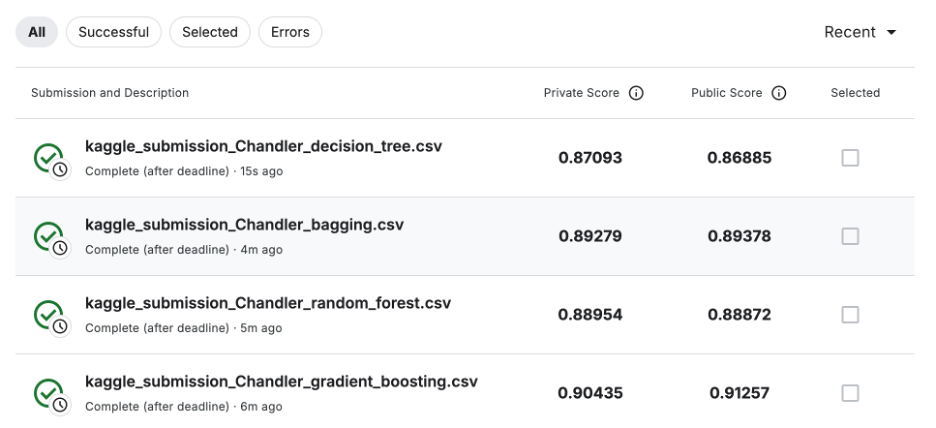

# Conclusion

This analysis evaluated tree-based statistical learning methods across two applied tasks. In the Boston housing dataset, all ensemble methods substantially outperformed both the single decision tree and linear regression baseline, with gradient boosting achieving the lowest test MSE. Random forests identified `lstat` and `rm` as the dominant predictors of median home value, providing interpretable variable importance alongside strong predictive performance.

In the multi-class obesity risk prediction task, four tree-based models were implemented under consistent preprocessing procedures. The single decision tree provided a transparent, interpretable baseline, while bagging reduced its variance. The random forest offered additional decorrelation benefits and competitive accuracy, and gradient boosting achieved the highest holdout accuracy through sequential residual correction.

Overall, the results reinforce the core bias-variance tradeoff framework in statistical learning. Ensemble methods reduce prediction error by pooling information across many trees, either through averaging (bagging, random forest) or sequential correction (boosting). Across both tasks evaluated here, gradient boosting consistently achieved the strongest predictive performance, while random forests provided a compelling balance of accuracy and interpretability through variable importance rankings.

# References

Breiman, L., Friedman, J., Olshen, R., & Stone, C. (1984). *Classification and regression trees*. Wadsworth.

Breiman, L. (1996). Bagging predictors. *Machine Learning, 24*(2), 123–140. https://doi.org/10.1007/BF00058655

Breiman, L. (2001). Random forests. *Machine Learning, 45*(1), 5–32. https://doi.org/10.1023/A:1010933404324

Friedman, J. H. (2001). Greedy function approximation: A gradient boosting machine. *Annals of Statistics, 29*(5), 1189–1232. https://doi.org/10.1214/aos/1013203451

Hastie, T., Tibshirani, R., & Friedman, J. (2009). *Elements of statistical learning: Data mining, inference, and prediction* (2nd ed.). Springer. https://hastie.su.domains/ElemStatLearn/

James, G., Witten, D., Hastie, T., Tibshirani, R., & Taylor, J. (2023). *An introduction to statistical learning with applications in Python*. Springer. https://www.statlearning.com

Reade, W., & Chow, A. (2024). Playground Series – Season 4, Episode 2 (Obesity Risk). Kaggle. https://kaggle.com/playground-series-s4e2

# AI Disclosure and Usage Statement

In accordance with the course policy on academic integrity, I acknowledge the use of Claude Sonnet 4.6 (a large language model developed by Anthropic) as a research and brainstorming tool for this assignment. The AI was used to assist in structuring portions of the written analysis, refining technical explanations of tree-based methods and ensemble learning, and troubleshooting Python implementation details within the Jupyter Notebook environment. All AI-generated suggestions were critically evaluated for accuracy, verified against course materials and dataset outputs, and substantially revised to reflect my own analytical reasoning and professional voice. The final model implementation, statistical interpretation, and conclusions represent my independent work and judgment.